In [ ]:
# Setup and Configuration
import os, random
import numpy as np
import torch
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "data" / "mnist"


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

In [2]:
"""
Shared utilities for CA3 experiments: seeding, I/O, and visualization.
"""

from pathlib import Path
import random
import json
import subprocess
from datetime import datetime
from typing import Dict, Any, Optional

import numpy as np
import torch
from torchvision.utils import make_grid, save_image


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def save_grid(
    images: torch.Tensor, path: Path, nrow: int = 8, normalize: bool = True
) -> None:
    ensure_dir(path.parent)
    grid = make_grid(images, nrow=nrow, normalize=normalize, value_range=(0, 1))
    save_image(grid.detach().cpu(), path)


def _repo_root() -> Path:
    """Return repository root (four levels up from this file)."""
    return Path(__file__).resolve().parents[3]


def git_commit_hash() -> str:
    """Short git hash for experiment tracking."""
    try:
        result = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"],
            cwd=_repo_root(),
            check=True,
            capture_output=True,
            text=True,
        )
        return result.stdout.strip()
    except Exception:
        return "unknown"


def write_run_info(
    output_dir: Path,
    configs: Dict[str, Any],
    notes: Optional[Dict[str, Any]] = None,
    device: Optional[str] = None,
) -> Path:
    """
    Persist minimal metadata for reproducibility.

    Args:
        output_dir: Directory where the JSON will be written.
        configs: Mapping of config names to dicts (e.g., {"data": ..., "model": ...}).
        notes: Optional free-form metadata (script name, purpose, etc.).
        device: Device string override; defaults to detected device.
    """
    ensure_dir(output_dir)

    def _to_jsonable(value: Any):
        if isinstance(value, dict):
            return {k: _to_jsonable(v) for k, v in value.items()}
        if isinstance(value, (list, tuple)):
            return [_to_jsonable(v) for v in value]
        if isinstance(value, Path):
            return str(value)
        if isinstance(value, torch.device):
            return str(value)
        return value

    payload: Dict[str, Any] = {
        "timestamp_utc": datetime.utcnow().isoformat() + "Z",
        "git_commit": git_commit_hash(),
        "device": device or ("cuda" if torch.cuda.is_available() else "cpu"),
        "configs": _to_jsonable(configs),
    }
    if notes:
        payload["notes"] = notes

    run_file = output_dir / "run_info.json"
    run_file.write_text(json.dumps(payload, indent=2))
    return run_file


In [3]:
!pip install torch torchvision tqdm numpy matplotlib


In [60]:
"""
Central configuration dataclasses for CA3 assignments.
All defaults align with the HW3 specification.
"""

from dataclasses import dataclass, field
from pathlib import Path
import torch


def default_device() -> torch.device:
    """Prefer CUDA when available; fall back to CPU."""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass
class RunPaths:
    # Use current working directory since __file__ isn't available in notebooks
    root: Path = Path.cwd() 
    images: Path = field(init=False)
    checkpoints: Path = field(init=False)

    def __post_init__(self):
        # Set paths relative to the root
        self.images = self.root / "images"
        self.checkpoints = self.root / "checkpoints"

    def ensure(self) -> None:
        for path in [self.images, self.checkpoints]:
            path.mkdir(parents=True, exist_ok=True)

@dataclass
class DataConfig:
    batch_size: int = 64
    num_workers: int = 2
    pin_memory: bool = True
    seed: int = 42
    image_size: int = 28
    channels: int = 1


@dataclass
class EBMConfig:
    epochs: int = 15
    lr: float = 1e-4             # کمی کمتر از 2e-4 برای پایداری بیشتر (پیشنهادی)
    lambda_reg: float = 0.15      # (اختیاری: 0.1 معمولاً بهتر از 0.01 جواب می‌دهد)
    
    langevin_step_size: float = 1.0   # عالی (اصلی‌ترین عامل موفقیت)
    langevin_steps: int = 60          # مناسب
    
    langevin_noise_scale: float = 0.01 # کمی افزایش دادیم (از 0.005 به 0.01)
    
    clamp_min: float = -1.0 
    clamp_max: float = 1.0  
    log_interval: int = 100
    sample_grid: int = 16
    device: torch.device = field(default_factory=default_device)

from dataclasses import dataclass, field
import torch

def default_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

@dataclass
class NCSNConfig:
    # --- پارامترهای دیتا ---
    image_size: int = 28
    channels: int = 1
    num_classes: int = 10
    
    # --- پارامترهای مدل ---
    embed_dim: int = 128       # ابعاد امبدینگ نویز (256 هم خوبه ولی 128 برای MNIST کافیه)
    conditional: bool = False  # بعدا موقع اجرا True می‌کنید
    
    # --- پارامترهای آموزش ---
    epochs: int = 50           # اسکور مچینگ دیرتر همگرا میشه، ۵۰ تا مطمئن‌تره
    lr: float = 1e-4           # نرخ یادگیری استاندارد آدام
    batch_size: int = 64       # بچ سایز بزرگتر = گرادیان پایدارتر (اگر مموری پر شد، ۳۲ کنید)
    num_workers: int = 2
    
    # --- پارامترهای نویز (بسیار مهم) ---
    sigma_begin: float = 30.0  # نویز اولیه (باید کل تصویر رو بپوشونه)
    sigma_end: float = 0.01    # نویز نهایی (دقت جزییات)
    num_levels: int = 50       # 🔴 تغییر مهم: از ۱۰ به ۵۰ افزایش یافت (برای تغییر نرم نویز)
    
    # --- پارامترهای سمپلینگ (Langevin) ---
    langevin_steps: int = 100  # تعداد قدم‌ها در هر سطح نویز
    step_lr: float = 2e-5      # سایز قدم پایه (خیلی حساس!)
    
    device: torch.device = field(default_factory=default_device)

    @property
    def sigmas(self):
        """تولید دنباله هندسی (Geometric Progression) از سیگماها"""
        # سیگماها باید به صورت لگاریتمی-خطی کاهش پیدا کنند
        return torch.exp(
            torch.linspace(
                torch.log(torch.tensor(self.sigma_begin)),
                torch.log(torch.tensor(self.sigma_end)),
                self.num_levels,
            )
        ).to(self.device)

In [5]:
# Configs

data_cfg = DataConfig()
ebm_cfg = EBMConfig(device=device)
ncsn_cfg = NCSNConfig(device=device)
paths = RunPaths()
paths.ensure()
data_cfg, ebm_cfg, ncsn_cfg

(DataConfig(batch_size=64, num_workers=2, pin_memory=True, seed=42, image_size=28, channels=1),
 EBMConfig(epochs=15, lr=0.0001, lambda_reg=0.1, langevin_step_size=1.0, langevin_steps=60, langevin_noise_scale=0.01, clamp_min=-1.0, clamp_max=1.0, log_interval=100, sample_grid=16, device=device(type='cuda')),
 NCSNConfig(epochs=30, lr=0.0002, batch_size=32, num_workers=2, sigma_begin=30.0, sigma_end=0.01, num_levels=10, langevin_steps=150, step_lr=2e-05, image_size=28, channels=1, embed_dim=128, conditional=False, num_classes=10, device=device(type='cuda')))

In [6]:
"""
MNIST data loading utilities.
"""

from pathlib import Path
from typing import Tuple
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


def mnist_dataloaders(
    cfg: DataConfig, normalize_to_minus1_1: bool = False
) -> Tuple[DataLoader, DataLoader]:
    set_seed(cfg.seed)
    transform_list = [transforms.ToTensor()]
    if normalize_to_minus1_1:
        transform_list.append(transforms.Normalize((0.5,), (0.5,)))
    transform = transforms.Compose(transform_list)
    data_root = Path(DATA_ROOT).resolve().parent.parent / "data" / "mnist"
    train_ds = datasets.MNIST(
        root=data_root, train=True, download=True, transform=transform
    )
    test_ds = datasets.MNIST(
        root=data_root, train=False, download=True, transform=transform
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory,
    )
    return train_loader, test_loader


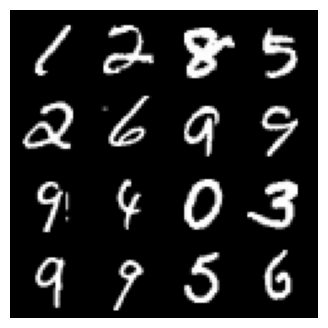

In [7]:
# Data loading and a quick peek
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

train_loader, test_loader = mnist_dataloaders(data_cfg, normalize_to_minus1_1=False)
images, labels = next(iter(train_loader))
grid = make_grid(images[:16], nrow=4)
save_image(grid.detach().cpu(), paths.images / "mnist_sample.png")
plt.figure(figsize=(4, 4))
plt.axis("off")
img_arr = grid.permute(1, 2, 0).detach().cpu().numpy()
plt.imshow(img_arr)
plt.show()

In [8]:
import torch
from torch import nn

# --- ۱. اصلاح مدل (تغییر LeakyReLU به SiLU) ---
class ConvEnergyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.SiLU(),  # تغییر مهم: LeakyReLU -> SiLU
            
            nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.SiLU(),
            
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.SiLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.SiLU(),
            
            nn.AdaptiveAvgPool2d(output_size=1),
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.net(x)
        h = h.view(h.size(0), -1)
        energy = self.fc(h)
        return energy.squeeze(-1)

# --- ۲. اصلاح سمپلر (منطق درست است، فقط کانفیگ باید استپ‌سایز ۱ داشته باشد) ---
class LangevinSampler:
    def __init__(self, model: nn.Module, cfg): # cfg: EBMConfig
        self.model = model
        self.cfg = cfg

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        step_size = self.cfg.langevin_step_size
        # فرمول نویز اسکیل درست است
        noise_scale = self.cfg.langevin_noise_scale * (2 * step_size) ** 0.5
        
        xk = x
        for _ in range(self.cfg.langevin_steps):
            xk = xk.detach().requires_grad_(True)
            energy = self.model(xk).sum()
            grad = torch.autograd.grad(energy, xk)[0]
            
            # معادله لانژون: حرکت خلاف جهت انرژی + نویز
            xk = xk - step_size * grad + noise_scale * torch.randn_like(xk)
            
            # کلمپ کردن بسیار مهم است
            xk = xk.clamp(self.cfg.clamp_min, self.cfg.clamp_max)
            
        return xk.detach()

# --- ۳. اصلاح تولید نویز اولیه (بسیار مهم) ---
def sample_from_noise(model: nn.Module, cfg, shape) -> torch.Tensor:
    # تغییر مهم: rand -> (2*rand - 1)
    # نویز باید کل فضای [-1, 1] را پوشش دهد
    init = 2 * torch.rand(shape, device=cfg.device) - 1
    sampler = LangevinSampler(model, cfg)
    return sampler(init)

def sample_with_trajectory(model: nn.Module, cfg, shape, record_every: int = 10):
    step_size = cfg.langevin_step_size
    noise_scale = cfg.langevin_noise_scale * (2 * step_size) ** 0.5
    
    # تغییر مهم: اصلاح بازه نویز در اینجا هم لازم است
    xk = 2 * torch.rand(shape, device=cfg.device) - 1
    
    traj = [xk.detach().cpu().clone()]
    for i in range(cfg.langevin_steps):
        xk = xk.detach().requires_grad_(True)
        energy = model(xk).sum()
        grad = torch.autograd.grad(energy, xk)[0]
        xk = xk - step_size * grad + noise_scale * torch.randn_like(xk)
        xk = xk.clamp(cfg.clamp_min, cfg.clamp_max)
        if (i + 1) % record_every == 0 or i == cfg.langevin_steps - 1:
            traj.append(xk.detach().cpu().clone())
    return traj

In [9]:
import torch
from torch import nn

class LangevinSampler:
    def __init__(self, model: nn.Module, cfg):
        self.model = model
        self.cfg = cfg

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        # تغییر ۱: اطمینان از استپ سایز بزرگ
        # (اگر در کانفیگ ۱.۰ گذاشتید اینجا مشکلی نیست، ولی محض احتیاط)
        step_size = self.cfg.langevin_step_size 
        
        noise_scale = self.cfg.langevin_noise_scale * (2 * step_size) ** 0.5
        xk = x
        
        for _ in range(self.cfg.langevin_steps):
            xk = xk.detach().requires_grad_(True)
            
            # محاسبه انرژی
            energy = self.model(xk).sum()
            
            # محاسبه گرادیان
            grad = torch.autograd.grad(energy, xk)[0]
            
            # آپدیت لانژون: حرکت در خلاف جهت انرژی + نویز
            xk = xk - step_size * grad + noise_scale * torch.randn_like(xk)
            
            # تغییر ۲: کلمپ کردن بسیار مهم است
            xk = xk.clamp(self.cfg.clamp_min, self.cfg.clamp_max)
            
        return xk.detach()


def sample_from_noise(model: nn.Module, cfg, shape) -> torch.Tensor:
    # 🔴 تغییر حیاتی: تولید نویز در بازه [-1, 1]
    # قبلی: torch.rand(...) -> [0, 1] (غلط)
    # جدید: 2 * torch.rand(...) - 1 -> [-1, 1] (صحیح)
    init = 2 * torch.rand(shape, device=cfg.device) - 1
    
    sampler = LangevinSampler(model, cfg)
    return sampler(init)


def sample_with_trajectory(model: nn.Module, cfg, shape, record_every: int = 10):
    step_size = cfg.langevin_step_size
    noise_scale = cfg.langevin_noise_scale * (2 * step_size) ** 0.5
    
    # 🔴 اینجا هم باید بازه اصلاح شود
    xk = 2 * torch.rand(shape, device=cfg.device) - 1
    
    traj = [xk.detach().cpu().clone()]
    for i in range(cfg.langevin_steps):
        xk = xk.detach().requires_grad_(True)
        energy = model(xk).sum()
        grad = torch.autograd.grad(energy, xk)[0]
        xk = xk - step_size * grad + noise_scale * torch.randn_like(xk)
        xk = xk.clamp(cfg.clamp_min, cfg.clamp_max)
        if (i + 1) % record_every == 0 or i == cfg.langevin_steps - 1:
            traj.append(xk.detach().cpu().clone())
    return traj

In [10]:
"""
Training loop for the MNIST Energy-Based Model with Langevin sampling.
Saves sample grids during training and checkpoints the model.
"""

import matplotlib.pyplot as plt
from dataclasses import asdict
from pathlib import Path
from typing import Dict, Any
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

import torch
from torch import optim
from tqdm import tqdm
def train(cfg_data: DataConfig, cfg_model: EBMConfig, output_dir: Path) -> Dict[str, Any]:
    set_seed(cfg_data.seed)
    
    # تنظیمات دیتالودر
    train_loader, _ = mnist_dataloaders(cfg_data)
    device = cfg_model.device

    model = ConvEnergyModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg_model.lr)
    sampler = LangevinSampler(model, cfg_model)
    
    # بافر
    buffer = SampleBuffer(max_size=10000)

    history = {"loss": [], "E_real": [], "E_fake": []}
    ensure_dir(output_dir)
    
    # (حذف کردیم) checkpoint_path ثابت دیگر اینجا تعریف نمی‌شود

    print(f"🚀 Starting training on {device}...")

    for epoch in range(1, cfg_model.epochs + 1):
        model.train()
        progress = tqdm(train_loader, desc=f"Epoch {epoch}/{cfg_model.epochs}", leave=False)
        
        for step, (x_real, _) in enumerate(progress, start=1):
            x_real = x_real.to(device)
            batch_size = x_real.shape[0]

            # --- مدیریت بافر ---
            use_buffer = torch.rand(1).item() > 0.05
            if use_buffer and len(buffer.buffer) >= batch_size:
                x_init = buffer.get(batch_size, device)
            else:
                x_init = torch.randn_like(x_real)

            # --- تولید نمونه ---
            # مدل را موقتاً به eval می‌بریم تا لایه‌هایی مثل Dropout روی نویز تاثیر نگذارند
            model.eval()
            x_fake = sampler(x_init)
            model.train()
            
            buffer.add(x_fake.detach())

            # --- محاسبه Loss ---
            E_real = model(x_real)
            E_fake = model(x_fake.detach()) 
            
            loss_data = E_real.mean() - E_fake.mean()
            loss_reg = cfg_model.lambda_reg * (E_real.pow(2).mean() + E_fake.pow(2).mean())
            
            loss = loss_data + loss_reg

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history["loss"].append(loss.item())
            history["E_real"].append(E_real.mean().item())
            history["E_fake"].append(E_fake.mean().item())

            if step % cfg_model.log_interval == 0:
                progress.set_postfix(loss=f"{loss.item():.3f}")

        # --- پایان هر اپوک: ذخیره مدل ---
        
        # 1. ذخیره نمونه تصاویر
        with torch.no_grad():
            viz_samples = buffer.get(16, device)
            save_grid(viz_samples, output_dir / f"samples_epoch_{epoch}.png", nrow=4)
        
        # 2. 🔴 ذخیره چک‌پوینت با نام منحصر به فرد
        # نام فایل شامل شماره اپوک است: ebm_ckpt_epoch_1.pt, ebm_ckpt_epoch_2.pt, ...
        ckpt_name = f"ebm_ckpt_epoch_{epoch}.pt"
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(), # ذخیره اپتیمایزر برای ادامه آموزش مفید است
            "epoch": epoch,
            "config": asdict(cfg_model) # ذخیره کانفیگ هم ایده خوبی است
        }, output_dir / ckpt_name)
        
        # (اختیاری) ذخیره یک نسخه به عنوان "latest" برای دسترسی سریع
        torch.save({
            "model": model.state_dict(),
            "epoch": epoch
        }, output_dir / "ebm_ckpt_latest.pt")

    return history



def train_interactive(
    cfg_data: DataConfig,
    cfg_model: EBMConfig,
    output_dir: Path,
    epochs: int = 1,
    show: bool = True,
):
    """Interactive/demo training for quick runs inside notebooks.

    Runs a small number of epochs, saves demo samples/loss plots to `output_dir`,
    and optionally displays sample grids inline when `show` is True.
    """
    # Backwards-compatible: allow calling with (train_loader, test_loader, cfg_model, ...)
    if isinstance(cfg_data, DataLoader):
        train_loader = cfg_data
        test_loader = cfg_model
        # third positional arg was passed into output_dir; interpret it as cfg_model
        cfg_model = output_dir
        # default demo output directory if not provided
        output_dir = Path("./outputs/ebm_demo")
        try:
            set_seed(cfg_model.seed)
        except Exception:
            # If seed isn't available, ignore
            pass
    else:
        set_seed(cfg_data.seed)
        # Cap batch size for interactive/demo runs on GPU to avoid OOM
        if cfg_model.device.type == "cuda":
            cfg_data.batch_size = min(cfg_data.batch_size, 32)
            cfg_data.num_workers = min(getattr(cfg_data, "num_workers", 2), 2)
        train_loader, test_loader = mnist_dataloaders(cfg_data)
    device = cfg_model.device

    model = ConvEnergyModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg_model.lr)
    sampler = LangevinSampler(model, cfg_model)

    history = {"loss": []}
    ensure_dir(output_dir)

    try:
        for epoch in range(1, epochs + 1):
            loop = tqdm(train_loader, desc=f"EBM demo epoch {epoch}/{epochs}", leave=False)
            for x_real, _ in loop:
                x_real = x_real.to(device)
                x_fake = sampler(torch.rand_like(x_real))

                E_real = model(x_real)
                E_fake = model(x_fake)

                data_term = E_real.mean() - E_fake.detach().mean()
                reg_term = cfg_model.lambda_reg * (
                    E_real.pow(2).mean() + E_fake.detach().pow(2).mean()
                )
                loss = data_term + reg_term

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                history["loss"].append(loss.item())
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("CUDA out of memory during EBM demo training.\nSuggestions: reduce `ebm_cfg.langevin_steps` or reduce batch size via `DataConfig(batch_size=...)`, or run on CPU (set `device=torch.device('cpu')`).\nAborting demo run.")
            try:
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            except Exception:
                pass
        raise

        # Sampling uses input gradients; do not disable grads here
        samples = sample_from_noise(model, cfg_model, (cfg_model.sample_grid, 1, 28, 28))
        save_grid(samples.detach().cpu(), output_dir / f"ebm_demo_samples_epoch{epoch}.png", nrow=4)

        if show:
            try:
                import matplotlib.pyplot as plt

                grid = make_grid(samples, nrow=4, normalize=True)
                img_arr = grid.permute(1, 2, 0).detach().cpu().numpy()
                plt.figure(figsize=(4, 4))
                plt.axis("off")
                plt.imshow(img_arr)
                plt.show()
            except Exception:
                # Best-effort display; continue even if matplotlib is unavailable.
                pass

    return model, history




In [11]:
class SampleBuffer:
    def __init__(self, max_size=10000):
        self.max_size = max_size
        self.buffer = []

    def add(self, samples):
        # ذخیره نمونه‌های جدید در بافر
        samples = samples.detach().cpu()
        for i in range(len(samples)):
            if len(self.buffer) < self.max_size:
                self.buffer.append(samples[i:i+1])
            else:
                # جایگزینی تصادفی در صورت پر بودن بافر
                idx = torch.randint(0, self.max_size, (1,)).item()
                self.buffer[idx] = samples[i:i+1]

    def get(self, n_samples, device):
        # اگر بافر خالی است، نویز برگردان
        if len(self.buffer) < n_samples:
            return (torch.rand(n_samples, 1, 28, 28) * 2 - 1).to(device)
        
        # انتخاب تصادفی از بافر
        idxs = torch.randint(0, len(self.buffer), (n_samples,))
        samples = torch.cat([self.buffer[i] for i in idxs], dim=0)
        return samples.to(device)

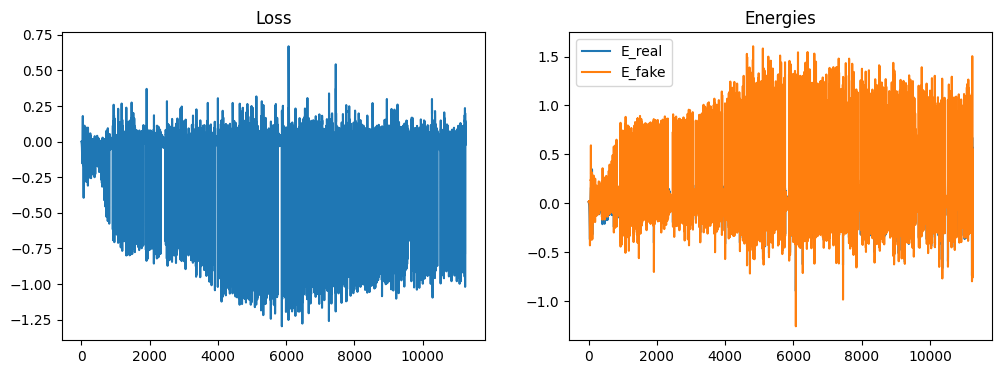

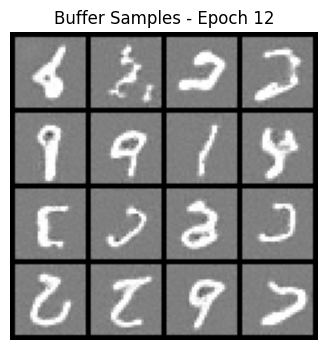

ValueError: too many values to unpack (expected 2)

In [28]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
# 1. تنظیم مجدد کانفیگ برای بازسازی مدل سالم
# فقط ۱۲ اپوک (نقطه اوج مدل قبل از خراب شدن)
re_train_cfg = EBMConfig(
    epochs=12,           # <--- مهم: اینجا متوقف می‌شویم
    lr=1e-4,             # همان نرخ یادگیری قبلی
    langevin_step_size=1.0,
    langevin_steps=60,
    langevin_noise_scale=0.01,
    device=device
)

data_cfg = DataConfig(batch_size=64)

# مسیر ذخیره‌سازی جدید (که با قبلی قاطی نشود)
save_dir = Path("saved_models/fixed_model")
save_dir.mkdir(parents=True, exist_ok=True)

print("♻️ Retraining model from scratch (Stop at Epoch 12)...")

# 2. اجرای آموزش
# فرض بر این است که تابع train شما در حافظه موجود است
model, history = train(data_cfg, re_train_cfg, output_dir=save_dir)

print("\n✅ Training finished!")
print(f"✅ Healthy model saved at: {save_dir / 'ebm_ckpt.pt'}")
history = train(
    cfg_data=data_cfg, 
    cfg_model=ebm_cfg, 
    output_dir=paths.images
)

print("Training complete. Check the 'images' folder for generated digit grids.")

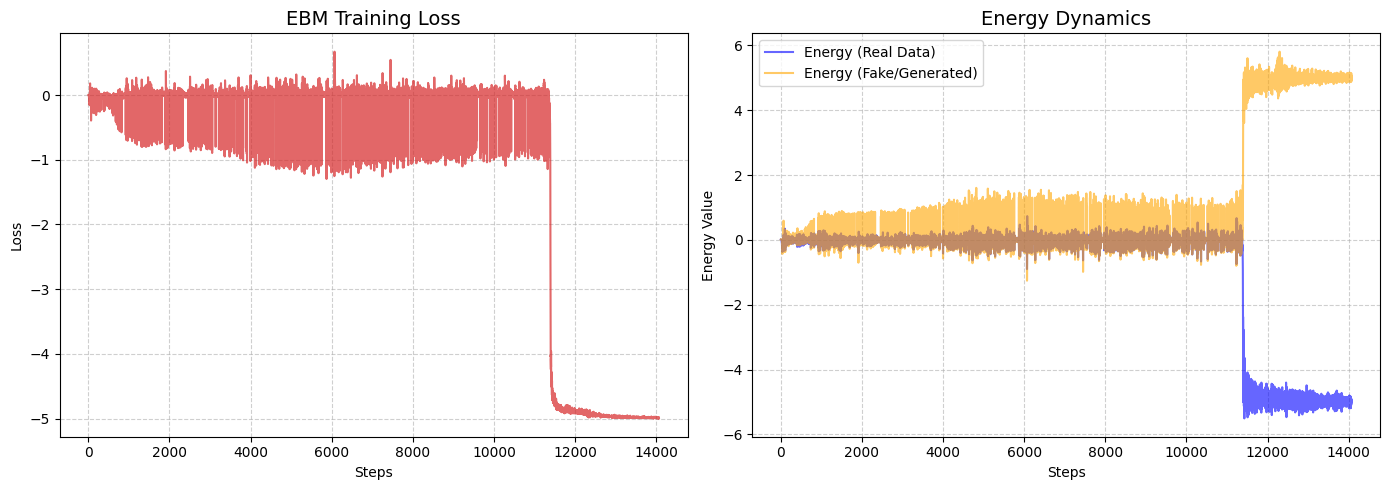

In [30]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Total Loss
    ax[0].plot(history["loss"], color='tab:red', alpha=0.7)
    ax[0].set_title("EBM Training Loss", fontsize=14)
    ax[0].set_xlabel("Steps")
    ax[0].set_ylabel("Loss")
    ax[0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Energies (Real vs Fake)
    ax[1].plot(history["E_real"], label="Energy (Real Data)", color='blue', alpha=0.6)
    ax[1].plot(history["E_fake"], label="Energy (Fake/Generated)", color='orange', alpha=0.6)
    ax[1].set_title("Energy Dynamics", fontsize=14)
    ax[1].set_xlabel("Steps")
    ax[1].set_ylabel("Energy Value")
    ax[1].legend()
    ax[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Use the history returned from your training function
plot_training_results(history)

In [31]:
"""
Inference helpers for the trained EBM: generation from noise and denoising.
"""

from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid


def load_model(checkpoint: Path, device: torch.device) -> ConvEnergyModel:
    model = ConvEnergyModel().to(device)
    state = torch.load(checkpoint, map_location=device)
    model.load_state_dict(state["model"])
    model.eval()
    return model


def show_tensor_image(tensor, title=None):
    """تابع کمکی برای نمایش تنسورهای [-1, 1] به صورت تصویر"""
    # تبدیل بازه [-1, 1] به [0, 1]
    tensor = (tensor.detach().cpu() + 1) / 2.0
    tensor = tensor.clamp(0, 1)
    
    # ساخت گرید (چیدمان شبکه‌ای)
    grid = make_grid(tensor, nrow=4, padding=2)
    
    # تبدیل برای ماتپلات‌لیب: (C, H, W) -> (H, W, C)
    np_img = grid.permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(6, 6))
    plt.imshow(np_img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def generate_and_denoise(
    checkpoint: Path,
    output_dir: Path,
    data_cfg: DataConfig,
    ebm_cfg: EBMConfig,
    noise_levels: list = None,
) -> None:
    set_seed(data_cfg.seed)
    train_loader, _ = mnist_dataloaders(data_cfg)
    ensure_dir(output_dir)
    
    model = load_model(checkpoint, ebm_cfg.device)
    sampler = LangevinSampler(model, ebm_cfg)

    # 1. تولید نمونه از نویز خالص (Generation)
    print("Generating samples from noise...")
    samples = sample_from_noise(model, ebm_cfg, (16, 1, 28, 28))
    save_grid(samples.detach().cpu(), output_dir / "ebm_samples_final.png", nrow=4)
    
    # نمایش نمونه‌های تولید شده
    show_tensor_image(samples, title="Generated Samples from Noise")

    # 2. حذف نویز (Denoising)
    x_real, _ = next(iter(train_loader))
    x_real = x_real[:16].to(ebm_cfg.device)

    if noise_levels is None:
        noise_levels = [0.3]

    for nl in noise_levels:
        print(f"--- Denoising with Noise Level: {nl} ---")
        noise = torch.randn_like(x_real) * nl
        noisy = (x_real + noise).clamp(-1.0, 1.0) 
        
        denoised = sampler(noisy)
        
        # ذخیره در فایل
        save_grid(x_real.detach().cpu(), output_dir / f"ebm_real_{nl:.2f}.png", nrow=4)
        save_grid(noisy.detach().cpu(), output_dir / f"ebm_noisy_{nl:.2f}.png", nrow=4)
        save_grid(denoised.detach().cpu(), output_dir / f"ebm_denoised_{nl:.2f}.png", nrow=4)
        
        # نمایش تصاویر (اصل، نویزی، تمیز شده)
        plt.figure(figsize=(15, 5))
        
        # تصویر اصلی
        plt.subplot(1, 3, 1)
        grid_real = make_grid((x_real.cpu() + 1) / 2, nrow=4).permute(1, 2, 0)
        plt.imshow(grid_real.clamp(0, 1))
        plt.title("Original")
        plt.axis("off")
        
        # تصویر نویزی
        plt.subplot(1, 3, 2)
        grid_noisy = make_grid((noisy.cpu() + 1) / 2, nrow=4).permute(1, 2, 0)
        plt.imshow(grid_noisy.clamp(0, 1))
        plt.title(f"Noisy (Level {nl})")
        plt.axis("off")
        
        # تصویر تمیز شده
        plt.subplot(1, 3, 3)
        grid_denoised = make_grid((denoised.cpu() + 1) / 2, nrow=4).permute(1, 2, 0)
        plt.imshow(grid_denoised.clamp(0, 1))
        plt.title("Denoised (EBM Output)")
        plt.axis("off")
        
        plt.show()


def sample_and_save_trajectory(
    checkpoint: Path,
    output_dir: Path,
    ebm_cfg: EBMConfig,
    record_every: int = 5,
) -> None:
    """Load model and save trajectory frames for a sample generated by Langevin."""
    ensure_dir(output_dir)
    model = load_model(checkpoint, ebm_cfg.device)

    print("Generating trajectory...")
    traj = sample_with_trajectory(model, ebm_cfg, (16, 1, 28, 28), record_every=record_every)
    
    # ذخیره فریم‌ها
    for i, frame in enumerate(traj):
        save_grid(frame, output_dir / f"trajectory_{i:03d}.png", nrow=4)
    
    # نمایش فقط اولین و آخرین فریم برای شلوغ نشدن خروجی
    print(f"Trajectory saved with {len(traj)} frames.")
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    grid_start = make_grid((traj[0] + 1) / 2, nrow=4).permute(1, 2, 0)
    plt.imshow(grid_start.clamp(0, 1))
    plt.title("Start (Noise)")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    grid_end = make_grid((traj[-1] + 1) / 2, nrow=4).permute(1, 2, 0)
    plt.imshow(grid_end.clamp(0, 1))
    plt.title("End (Generated)")
    plt.axis("off")
    
    plt.show()

Loading from: saved_models/fixed_model/ebm_ckpt.pt
⏳ Generating fresh samples...


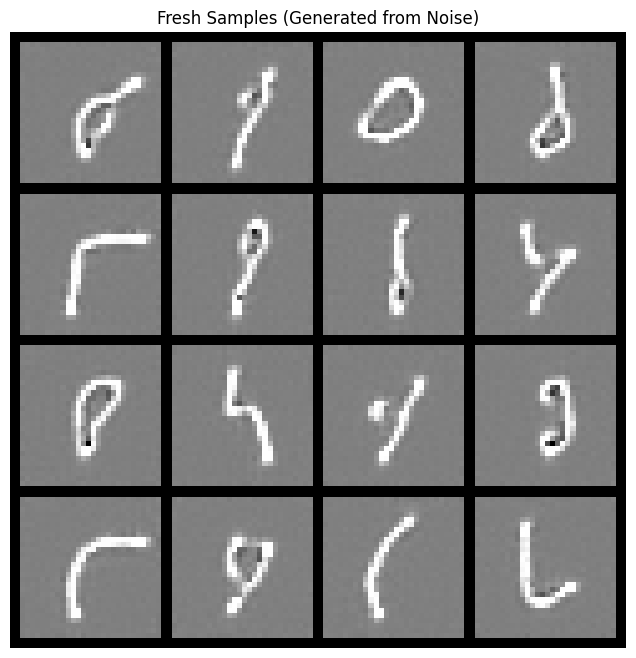

In [36]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path
import os

# 1. تنظیمات
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. لود کردن مدل (کدی که قبلا درست کار کرد)
checkpoint_path = save_dir / "ebm_ckpt.pt"

# if not checkpoint_path.exists():
#     # چک کردن مسیر جایگزین اگر مسیر بالا نبود
#     checkpoint_path = Path("checkpoints/ebm_best/ebm_ckpt.pt")

print(f"Loading from: {checkpoint_path}")
model = ConvEnergyModel().to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
if isinstance(checkpoint, dict) and "model" in checkpoint:
    model.load_state_dict(checkpoint["model"])
else:
    model.load_state_dict(checkpoint)
model.eval()

# 3. کانفیگ تست
test_cfg = EBMConfig(
    epochs=1, 
    lr=1e-4,
    langevin_step_size=0.1,   
    langevin_steps=10000,      
    langevin_noise_scale=0.005,
    device=device
)

# 4. تولید تصویر (بدون no_grad)
print("⏳ Generating fresh samples...")

# 🔴 نکته مهم: اینجا نباید torch.no_grad() باشد!
# چون سمپلر لانژون برای حرکت دادن پیکسل‌ها نیاز به گرادیان دارد.
fresh_samples = sample_from_noise(model, test_cfg, (16, 1, 28, 28))

# 5. نمایش
# برای نمایش مشکلی نیست که گرادیان را قطع کنیم تا رم آزاد شود
with torch.no_grad():
    grid_tensor = (fresh_samples.detach().cpu() + 1) / 2.0
    grid_tensor = grid_tensor.clamp(0, 1)
    grid = make_grid(grid_tensor, nrow=4, padding=2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    plt.title("Fresh Samples (Generated from Noise)")
    plt.axis('off')
    plt.show()

Generating samples from noise...


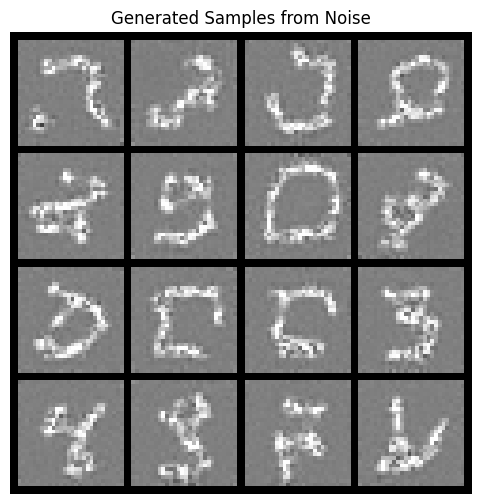

--- Denoising with Noise Level: 0.2 ---


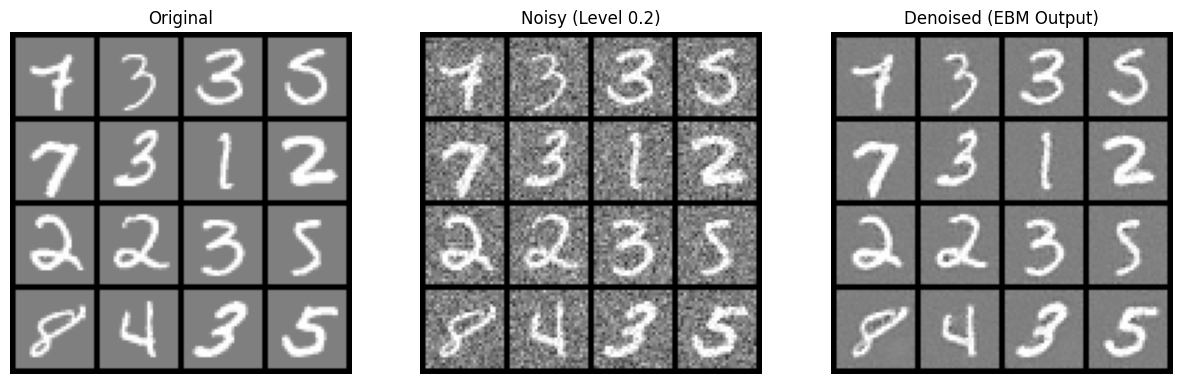

--- Denoising with Noise Level: 0.4 ---


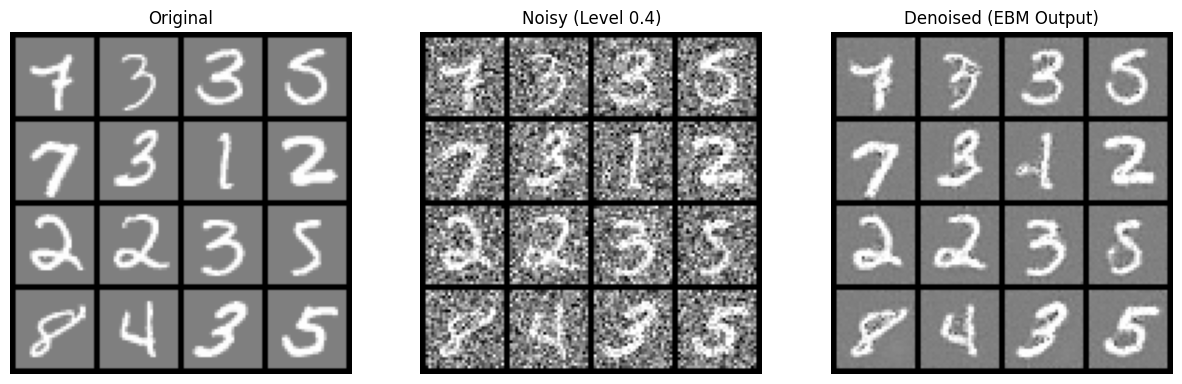

--- Denoising with Noise Level: 0.6 ---


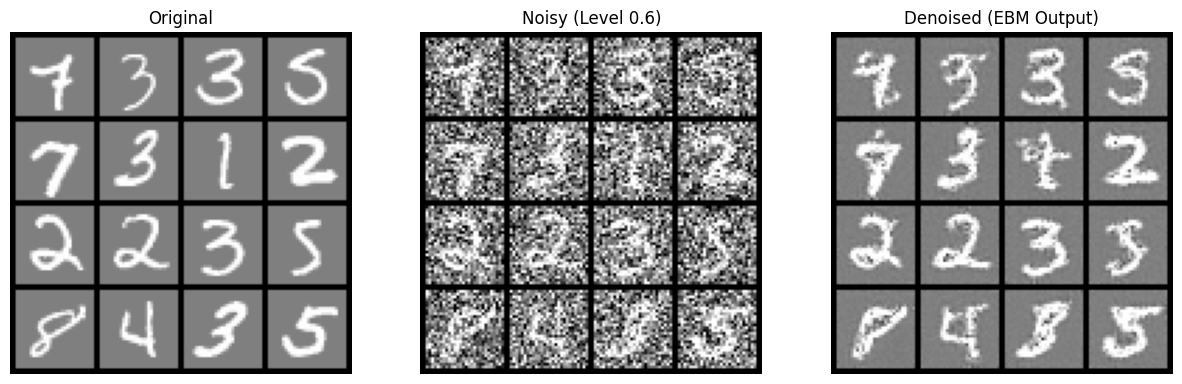

Inference complete! Check the 'inference_results' folder.


In [37]:
# 1. Define the path to your saved checkpoint from training
checkpoint_path = save_dir / "ebm_ckpt.pt" 

# 2. Run the generation and denoising helper
generate_and_denoise(
    checkpoint=checkpoint_path,
    output_dir=paths.images / "inference_results",
    data_cfg=data_cfg,
    ebm_cfg=ebm_cfg,
    noise_levels=[0.2, 0.4, 0.6]  # Specific levels from HW Subsection 4
)

print("Inference complete! Check the 'inference_results' folder.")

In [38]:
import imageio
from pathlib import Path

def make_gif_from_frames(frame_dir: Path, output_path: Path, prefix: str = "trajectory", fps: int = 8):
    """
    Combines PNG frames in a directory into an animated GIF.
    """
    # Find files starting with the specific prefix
    png_files = sorted(list(frame_dir.glob(f"{prefix}_*.png")))
    
    if not png_files:
        print(f"Error: No frames found in {frame_dir} with prefix '{prefix}'")
        return

    images = [imageio.imread(str(f)) for f in png_files]
    imageio.mimsave(output_path, images, fps=fps)
    print(f"GIF successfully created at {output_path}")

Generating trajectory...
Trajectory saved with 13 frames.


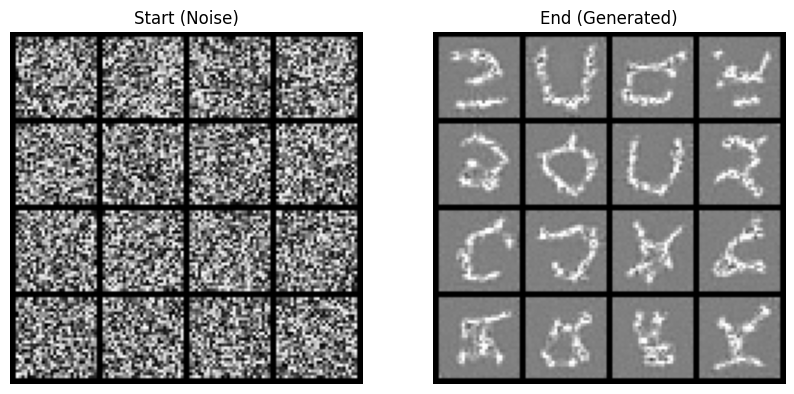

Trajectory frames saved to /kaggle/working/images/ebm_trajectory
GIF successfully created at /kaggle/working/images/ebm_trajectory.gif


/tmp/ipykernel_2836/3658658328.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(str(f)) for f in png_files]


In [40]:
# Trajectory visualization
ebm_ckpt = save_dir  / "ebm_ckpt.pt"
if ebm_ckpt.exists():
    traj_dir = paths.images / "ebm_trajectory"
    sample_and_save_trajectory(ebm_ckpt, traj_dir, EBMConfig(), record_every=5)
    print("Trajectory frames saved to", traj_dir)
    # Optionally create GIF
    make_gif_from_frames(traj_dir, paths.images / "ebm_trajectory.gif", fps=6)
else:
    print("EBM checkpoint not found.")

🧼 Running Smooth Denoising...


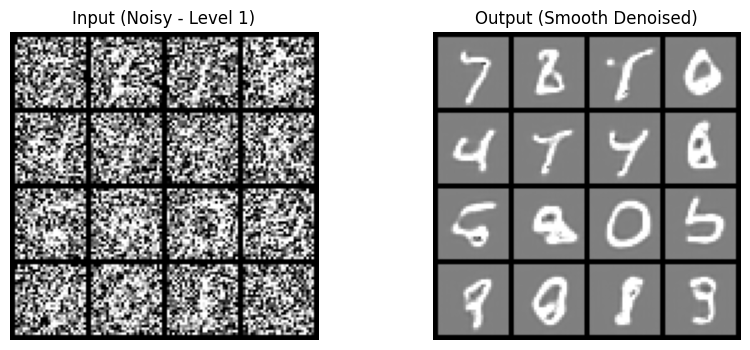

In [45]:
# تنظیمات مخصوص حذف نویز (خیلی ملایم‌تر از حالت تولید)
denoise_cfg = EBMConfig(
    langevin_steps=3000,       # تعداد قدم کمتر کافیه (چون تصویر قبلاً شکل داره)
    langevin_step_size=0.1,  # <--- راز موفقیت: قدم‌های خیلی ریز برای صیقل دادن
    langevin_noise_scale=0.0, # <--- قطع کردن نویز: ما نویز نمی‌خوایم، فقط تمیزی می‌خوایم!
    device=device
)

# تابعی برای اجرای Denoising با تنظیمات جدید
def smooth_denoise(model, noisy_images, cfg):
    # کپی گرفتن از تصویر نویزی به عنوان نقطه شروع
    current_img = noisy_images.clone().detach().requires_grad_(True)
    
    # حلقه لانژون (فقط حرکت به سمت انرژی پایین، بدون نویز اضافه)
    for _ in range(cfg.langevin_steps):
        energy = model(current_img)
        grad = torch.autograd.grad(energy.sum(), current_img)[0]
        
        # آپدیت پیکسل‌ها (حرکت خلاف جهت انرژی)
        current_img.data = current_img.data - cfg.langevin_step_size * grad
        
        # نگه داشتن در بازه [-1, 1]
        current_img.data = current_img.data.clamp(-1, 1)
        
    return current_img.detach()

# --- اجرای تست ---
print("🧼 Running Smooth Denoising...")

# گرفتن یک بچ داده
images, _ = next(iter(test_loader))
images = images[:16].to(device)

# اضافه کردن نویز دستی
noise_level = 1
noisy_inputs = images + noise_level * torch.randn_like(images)
noisy_inputs = noisy_inputs.clamp(-1, 1)

# تمیز کردن با تنظیمات جدید
with torch.enable_grad(): # برای محاسبه گرادیان لازم است
    cleaned = smooth_denoise(model, noisy_inputs, denoise_cfg)

# --- نمایش ---
plt.figure(figsize=(10, 4))

# ردیف ۱: نویزی
plt.subplot(1, 2, 1)
grid_noisy = make_grid((noisy_inputs.cpu() + 1) / 2, nrow=4)
plt.imshow(grid_noisy.permute(1, 2, 0).numpy(), cmap='gray')
plt.title(f"Input (Noisy - Level {noise_level})")
plt.axis('off')

# ردیف ۲: تمیز شده (صاف)
plt.subplot(1, 2, 2)
grid_clean = make_grid((cleaned.cpu() + 1) / 2, nrow=4)
plt.imshow(grid_clean.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Output (Smooth Denoised)")
plt.axis('off')

plt.show()

In [46]:
"""
Noise Conditional Score Network for MNIST (unconditional + class-conditional).
Implements Gaussian Fourier embeddings and FiLM-conditioned residual blocks.
"""

from typing import Tuple, Optional
import torch
from torch import nn
import torch.nn.functional as F


class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim: int, scale: float = 1.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)

    def forward(self, sigma: torch.Tensor) -> torch.Tensor:
        # sigma: (B,)
        proj = sigma[:, None] * self.W[None, :]
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


class AdaptiveResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, embed_dim: int):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm2 = nn.GroupNorm(32, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.emb_proj = nn.Linear(embed_dim, out_ch * 2)
        self.skip = (
            nn.Conv2d(in_ch, out_ch, kernel_size=1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor, emb: torch.Tensor) -> torch.Tensor:
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        scale_shift = self.emb_proj(emb)
        scale, shift = torch.chunk(scale_shift, 2, dim=1)
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        h = self.norm2(h)
        h = h * (1 + scale) + shift
        h = F.silu(h)
        h = self.conv2(h)
        return h + self.skip(x)


class ScoreNet(nn.Module):
    def __init__(self, cfg: NCSNConfig):
        super().__init__()
        self.cfg = cfg
        self.sigma_embed = GaussianFourierProjection(cfg.embed_dim, scale=1.0)
        self.emb_mlp = nn.Sequential(
            nn.Linear(cfg.embed_dim, cfg.embed_dim),
            nn.SiLU(),
            nn.Linear(cfg.embed_dim, cfg.embed_dim),
        )
        self.input_conv = nn.Conv2d(cfg.channels, 64, kernel_size=3, padding=1)

        self.enc1 = AdaptiveResBlock(64, 64, cfg.embed_dim)
        self.down1 = nn.AvgPool2d(2)
        self.enc2 = AdaptiveResBlock(64, 128, cfg.embed_dim)
        self.down2 = nn.AvgPool2d(2)
        self.enc3 = AdaptiveResBlock(128, 256, cfg.embed_dim)

        self.dec1 = AdaptiveResBlock(256 + 128, 128, cfg.embed_dim)
        self.dec2 = AdaptiveResBlock(128 + 64, 64, cfg.embed_dim)
        self.out_conv = nn.Conv2d(64, cfg.channels, kernel_size=3, padding=1)

        self.conditional = cfg.conditional
        if self.conditional:
            self.label_emb = nn.Embedding(cfg.num_classes, cfg.embed_dim)

    def forward(
        self, x: torch.Tensor, sigma: torch.Tensor, y: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        emb = self.sigma_embed(sigma)
        if self.conditional:
            if y is None:
                raise ValueError("Class labels required for conditional ScoreNet.")
            emb = emb + self.label_emb(y)
        emb = self.emb_mlp(emb)

        h0 = self.input_conv(x)
        h1 = self.enc1(h0, emb)
        h2 = self.enc2(self.down1(h1), emb)
        h3 = self.enc3(self.down2(h2), emb)

        u1 = F.interpolate(h3, scale_factor=2, mode="nearest")
        d1 = self.dec1(torch.cat([u1, h2], dim=1), emb)
        u2 = F.interpolate(d1, scale_factor=2, mode="nearest")
        d2 = self.dec2(torch.cat([u2, h1], dim=1), emb)
        out = self.out_conv(F.silu(d2))
        return out


In [47]:
"""
Weighted denoising score matching loss for NCSN.
"""

import torch
from torch import nn
from typing import Optional


def dsm_loss(
    model: nn.Module,
    x: torch.Tensor,
    cfg: NCSNConfig,
    sigmas: torch.Tensor,
    y: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    batch_size = x.size(0)
    # pick a noise level per-sample
    idx = torch.randint(0, cfg.num_levels, (batch_size,), device=x.device)
    sigma = sigmas[idx]
    noise = torch.randn_like(x)
    x_noisy = x + sigma.view(-1, 1, 1, 1) * noise

    score = model(x_noisy, sigma, y)
    target = -noise / sigma.view(-1, 1, 1, 1)
    loss = (
        0.5 * (score - target).pow(2).reshape(batch_size, -1).mean(dim=1) * (sigma**2)
    )
    return loss.mean()


In [48]:
"""
Annealed Langevin Dynamics sampling and denoising for NCSN.
"""

from typing import Optional
import torch
from torch import nn


@torch.no_grad()
def annealed_langevin_dynamics(model, cfg, sigmas, x, y):
    model.eval() # Ensure dropout/batchnorm are in eval mode
    for sigma in sigmas:
        # sigma.item() keeps the math simple and off the autograd graph
        step_size = cfg.step_lr * (sigma.item() / sigmas[-1].item()) ** 2
        for _ in range(cfg.langevin_steps):
            noise = torch.randn_like(x)
            score = model(x, sigma.expand(x.size(0)), y)
            x = x + step_size * score + (2 * step_size) ** 0.5 * noise
        x = x.clamp(-1.0, 1.0)
    return x

@torch.no_grad() # This is the most important line
def annealed_langevin_dynamics_with_trajectory(
    model: nn.Module,
    cfg: NCSNConfig,
    sigmas: torch.Tensor,
    x: torch.Tensor,
    y: Optional[torch.Tensor] = None,
    record_every: int = 10,
):
    model.eval() # Ensure model is in eval mode
    
    # Ensure starting x does not track gradients
    x = x.detach() 
    
    traj = [x.cpu().clone()]
    
    for sigma in sigmas:
        # Use .item() to keep the calculation off the GPU autograd engine
        step_size = cfg.step_lr * (sigma.item() / sigmas[-1].item()) ** 2
        
        for t in range(cfg.langevin_steps):
            noise = torch.randn_like(x)
            
            # The model call is now safe because of @torch.no_grad()
            score = model(x, sigma.expand(x.size(0)), y)
            
            x = x + step_size * score + (2 * step_size) ** 0.5 * noise
            
            if (t + 1) % record_every == 0:
                traj.append(x.cpu().clone())
        
        x = x.clamp(-1.0, 1.0)
        traj.append(x.cpu().clone())
        
        # # Optional: Force clean up between sigma levels
        # torch.cuda.empty_cache() 
        
    return traj



def sample(
    model: nn.Module,
    cfg: NCSNConfig,
    num_samples: int,
    y: Optional[torch.Tensor] = None,
    return_trajectory: bool = False,
    record_every: int = 10,
) -> torch.Tensor:
    x = torch.randn(
        num_samples, cfg.channels, cfg.image_size, cfg.image_size, device=cfg.device
    )
    sigmas = cfg.sigmas
    if return_trajectory:
        return annealed_langevin_dynamics_with_trajectory(model, cfg, sigmas, x, y, record_every)
    return annealed_langevin_dynamics(model, cfg, sigmas, x, y)


@torch.no_grad()
def denoise(
    model: nn.Module,
    cfg: NCSNConfig,
    images: torch.Tensor,
    noise_level: float,
    y: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    # use a single sigma value for denoising
    start_idx = (cfg.sigmas - noise_level).abs().argmin()
    # اجرای آنیلینگ از آنجا تا آخر (کمترین نویز)
    partial_sigmas = cfg.sigmas[start_idx:]
    return annealed_langevin_dynamics(model, cfg, partial_sigmas, images, y)

In [57]:
"""
Training pipeline for Noise Conditional Score Network (unconditional or conditional).
"""

import matplotlib.pyplot as plt
from dataclasses import asdict
from pathlib import Path
from typing import Dict, Any, Optional

import torch
from torch import optim
from tqdm import tqdm

from torchvision.utils import make_grid
from IPython.display import clear_output
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from dataclasses import asdict
from pathlib import Path
from typing import Dict, Any, Optional

import torch
from torch import optim
from tqdm import tqdm

from torchvision.utils import make_grid
from IPython.display import clear_output

# --- 1. THE MAIN TRAINING FUNCTION (Renamed from train_interactive to train) ---
def train(
    cfg: NCSNConfig, output_dir: Path, conditional: bool = False, epochs: int = 1
) -> Dict[str, Any]:
    
    # --- Setup & Config ---
    cfg.conditional = conditional
    set_seed(42)
    
    # Build Dataloader
    data_cfg = DataConfig(
        batch_size=cfg.batch_size, num_workers=cfg.num_workers, channels=cfg.channels
    )
    # Cap batch size if on GPU to avoid OOM
    if cfg.device.type == "cuda":
        data_cfg.batch_size = min(data_cfg.batch_size, 32) 
        
    train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)

    device = cfg.device
    model = ScoreNet(cfg).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    sigmas = cfg.sigmas 

    ensure_dir(output_dir)
    history = {"loss": []}
    
    print(f"Starting NCSN Training on {device}...")
    
    # --- Training Loop ---
    for epoch in range(1, epochs + 1):
        model.train()
        progress = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        
        epoch_loss = []
        
        for x, labels in progress:
            x = x.to(device)
            x = x * 2 - 1  # Map to [-1, 1]
            y = labels.to(device) if conditional else None

            # Calculate Loss
            loss = dsm_loss(model, x, cfg, sigmas, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history["loss"].append(loss.item())
            epoch_loss.append(loss.item())
            progress.set_postfix(loss=f"{loss.item():.3f}")

        # --- Visualization & Live Update (End of Epoch) ---
        
        # A) Generate new samples
        model.eval()
        y_samples = None
        if conditional:
            # Generate 0-9 
            y_samples = torch.arange(0, 16, device=device) % cfg.num_classes
            
        with torch.no_grad():
            samples = sample(model, cfg, num_samples=16, y=y_samples)
            # Map back to [0, 1] for display
            samples = (samples + 1) / 2.0
            samples = samples.clamp(0, 1).cpu()

        # B) Plotting
        clear_output(wait=True) 
        
        plt.figure(figsize=(12, 5))
        
        # Left: Loss
        plt.subplot(1, 2, 1)
        plt.plot(history["loss"], label="DSM Loss", alpha=0.7)
        plt.xlabel("Steps")
        plt.ylabel("Loss")
        plt.title(f"Training Loss (Epoch {epoch})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Right: Samples
        plt.subplot(1, 2, 2)
        grid_img = make_grid(samples, nrow=4, padding=2, normalize=False)
        plt.imshow(grid_img.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Generated Samples - Epoch {epoch}")
        
        plt.tight_layout()
        plt.show()
        
        # C) Save to disk
        save_grid(samples, output_dir / f"ncsn_samples_epoch{epoch}.png", nrow=4)
        torch.save({
            "model": model.state_dict(),
            "epoch": epoch,
            "config": asdict(cfg)
        }, output_dir / ("ncsn_cond.pt" if conditional else "ncsn.pt"))

    return model, history

# --- 2. THE INTERACTIVE DEMO FUNCTION ---
def train_interactive(
    cfg: NCSNConfig, output_dir: Path, conditional: bool = False, epochs: int = 1, show: bool = True
) -> Dict[str, Any]:
    """Interactive/demo training for quick runs inside notebooks."""
    
    # (Backward compatibility logic kept same as your provided code)
    from torch.utils.data import DataLoader
    if isinstance(cfg, DataLoader):
        train_loader = cfg
        cfg = output_dir
        output_dir = Path("./outputs/ncsn_demo")
        try: cfg.conditional = conditional
        except: pass
        try: set_seed(42)
        except: pass
        data_cfg = DataConfig(batch_size=cfg.batch_size, num_workers=2, channels=1)
    else:
        cfg.conditional = conditional
        set_seed(42)
        data_cfg = DataConfig(batch_size=cfg.batch_size, num_workers=cfg.num_workers, channels=cfg.channels)
        if cfg.device.type == "cuda":
            data_cfg.batch_size = min(data_cfg.batch_size, 16)
            data_cfg.num_workers = min(data_cfg.num_workers, 2)
        train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)

    device = cfg.device
    model = ScoreNet(cfg).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    sigmas = cfg.sigmas

    ensure_dir(output_dir)
    history = {"loss": []}
    checkpoint_path = output_dir / ("ncsn_cond.pt" if conditional else "ncsn.pt")
    
    # Training Loop
    try:
        for epoch in range(1, epochs + 1):
            progress = tqdm(train_loader, desc=f"NCSN demo epoch {epoch}/{epochs}", leave=False)
            for x, labels in progress:
                x = x.to(device)
                x = x * 2 - 1 
                y = labels.to(device) if conditional else None

                loss = dsm_loss(model, x, cfg, sigmas, y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                history["loss"].append(loss.item())
                progress.set_postfix(loss=f"{loss.item():.3f}")

            # Sampling per epoch
            y_samples = None
            if conditional:
                y_samples = torch.arange(0, 16, device=device) % cfg.num_classes
            
            with torch.no_grad():
                samples = sample(model, cfg, num_samples=16, y=y_samples)
                samples = (samples + 1) / 2.0
                samples = samples.clamp(0, 1)

            save_grid(samples.cpu(), output_dir / f"samples_epoch{epoch}.png", nrow=4)

            if show:
                try:
                    grid = make_grid(samples, nrow=4, normalize=False)
                    img_arr = grid.permute(1, 2, 0).cpu().numpy()
                    plt.figure(figsize=(4, 4))
                    plt.axis("off")
                    plt.imshow(img_arr)
                    plt.show()
                except Exception:
                    pass

            torch.save({"model": model.state_dict(), "epoch": epoch}, checkpoint_path)
            
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("CUDA OOM. Try reducing batch size.")
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        raise

    return model, history

def train_interactive(
    cfg: NCSNConfig, output_dir: Path, conditional: bool = False, epochs: int = 1, show: bool = True
) -> Dict[str, Any]:
    """Interactive/demo training for quick runs inside notebooks.

    Runs a small number of epochs, saves demo samples/loss plots to `output_dir`,
    and optionally displays sample grids inline when `show` is True.

    Backwards-compatible call signatures supported:
        - train_interactive(cfg, output_dir, ...)
        - train_interactive(train_loader, cfg, ...)  # notebook convenience (deprecated)
    """
    # Backwards-compat: if user passed (train_loader, cfg, ...)
    from torch.utils.data import DataLoader

    if isinstance(cfg, DataLoader):
        train_loader = cfg
        cfg = output_dir
        # default demo output directory if not provided
        output_dir = Path("./outputs/ncsn_demo")
        try:
            cfg.conditional = conditional
        except Exception:
            pass
        try:
            set_seed(42)
        except Exception:
            pass
        # Construct a DataConfig object for bookkeeping (used by write_run_info)
        data_cfg = DataConfig(
            batch_size=cfg.batch_size, num_workers=getattr(cfg, "num_workers", 2), channels=getattr(cfg, "channels", 1)
        )
    else:
        cfg.conditional = conditional
        set_seed(42)

        data_cfg = DataConfig(
            batch_size=cfg.batch_size, num_workers=cfg.num_workers, channels=cfg.channels
        )
        # Cap batch size for interactive/demo runs to avoid OOM on small GPUs
        if cfg.device.type == "cuda":
            data_cfg.batch_size = min(data_cfg.batch_size, 16)
            data_cfg.num_workers = min(data_cfg.num_workers, 2)
        train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)

    device = cfg.device
    model = ScoreNet(cfg).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    sigmas = cfg.sigmas

    ensure_dir(output_dir)
    history = {"loss": []}
    checkpoint_path = output_dir / ("ncsn_cond.pt" if conditional else "ncsn.pt")
    write_run_info(
        output_dir,
        configs={
            "data": asdict(data_cfg),
            "model": asdict(cfg),
            "conditional": {"enabled": conditional},
        },
        notes={"script": "ncsn_train.py (interactive)"},
        device=str(device),
    )

    try:
        for epoch in range(1, epochs + 1):
            progress = tqdm(
                train_loader, desc=f"NCSN demo epoch {epoch}/{epochs}", leave=False
            )
        for x, labels in progress:
            x = x.to(device)
            x = x * 2 - 1  # map to [-1, 1]
            y = labels.to(device) if conditional else None

            loss = dsm_loss(model, x, cfg, sigmas, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history["loss"].append(loss.item())
            progress.set_postfix(loss=f"{loss.item():.3f}")

        y_samples: Optional[torch.Tensor] = None
        if conditional:
            y_samples = torch.arange(0, 16, device=device) % cfg.num_classes
        samples = sample(model, cfg, num_samples=16, y=y_samples)
        samples = (samples + 1) / 2.0
        save_grid(samples.detach().cpu(), output_dir / f"samples_epoch{epoch}.png", nrow=4)

        if show:
            try:
                import matplotlib.pyplot as plt
                grid = make_grid(samples, nrow=4, normalize=True, value_range=(0, 1))
                img_arr = grid.permute(1, 2, 0).detach().cpu().numpy()
                plt.figure(figsize=(4, 4))
                plt.axis("off")
                plt.imshow(img_arr)
                plt.show()
            except Exception:
                pass

            torch.save(
                {
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "epoch": epoch,
                },
                checkpoint_path,
            )
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print("CUDA out of memory during NCSN demo training.\nSuggestions: reduce `ncsn_cfg.embed_dim`, reduce `ncsn_cfg.num_levels` or `ncsn_cfg.langevin_steps`, or run on CPU (set `device=torch.device('cpu')`).\nAborting demo run.")
            try:
                import torch

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            except Exception:
                pass
        raise

    # Save loss visualization
    try:
        plt.figure(figsize=(6, 4))
        plt.plot(history["loss"], label="DSM loss")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title("NCSN DSM Loss")
        plt.legend()
        plt.tight_layout()
        plt.savefig(output_dir / "ncsn_loss.png")
        plt.close()
    except Exception:
        # Best-effort plotting
        pass

    # Return model and history for interactive/demo usage
    return model, history




In [62]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from pathlib import Path
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from IPython.display import clear_output
from typing import Dict, Any, Optional
from dataclasses import asdict

# --- تعریف مجدد تابع train (مخصوص NCSN) ---
def train(
    cfg: NCSNConfig, output_dir: Path, conditional: bool = False, epochs: int = 30
) -> Dict[str, Any]:
    
    # 1. تنظیمات
    cfg.conditional = conditional
    set_seed(42)
    
    # ساخت دیتالودر
    data_cfg = DataConfig(
        batch_size=cfg.batch_size, num_workers=cfg.num_workers, channels=cfg.channels
    )
    if cfg.device.type == "cuda":
        data_cfg.batch_size = min(data_cfg.batch_size, 32)
        
    train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)

    device = cfg.device
    model = ScoreNet(cfg).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)
    sigmas = cfg.sigmas

    ensure_dir(output_dir)
    history = {"loss": []}
    
    print(f"🚀 Starting NCSN Training (Conditional={conditional}) on {device}...")
    
    # 2. حلقه آموزش
    for epoch in range(1, epochs + 1):
        model.train()
        progress = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        
        for x, labels in progress:
            x = x.to(device)
            x = x * 2 - 1  # انتقال به [-1, 1]
            y = labels.to(device) if conditional else None

            # محاسبه لاس (DSM)
            loss = dsm_loss(model, x, cfg, sigmas, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history["loss"].append(loss.item())
            progress.set_postfix(loss=f"{loss.item():.3f}")

        # 3. نمایش و ذخیره (پایان هر اپوک)
        clear_output(wait=True)
        
        # تولید نمونه
        model.eval()
        y_samples = None
        if conditional:
            y_samples = torch.arange(0, 16, device=device) % cfg.num_classes
            
        with torch.no_grad():
            # نمونه‌برداری با Annealed Langevin
            samples = sample(model, cfg, num_samples=16, y=y_samples)
            # نرمال‌سازی برای نمایش [0, 1]
            samples = (samples + 1) / 2.0
            samples = samples.clamp(0, 1).cpu()

        # رسم نمودارها
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history["loss"], label="DSM Loss", alpha=0.7)
        plt.title(f"Loss - Epoch {epoch}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.subplot(1, 2, 2)
        grid_img = make_grid(samples, nrow=4, padding=2)
        plt.imshow(grid_img.permute(1, 2, 0))
        plt.title(f"Samples - Epoch {epoch}")
        plt.axis("off")
        
        plt.show()
        
        # ذخیره فایل مدل
        ckpt_name = "ncsn_cond.pt" if conditional else "ncsn.pt"
        torch.save({
            "model": model.state_dict(),
            "epoch": epoch,
            "config": asdict(cfg)
        }, output_dir / ckpt_name)

    return model, history

# # --- اجرای اصلی ---
# def main():
#     # تنظیم مسیرها (فرض بر این است که آبجکت paths تعریف شده است)
#     # اگر تعریف نشده، یک مسیر پیش‌فرض می‌سازیم
#     base_dir = Path("./outputs/ncsn_experiment")
#     base_dir.mkdir(parents=True, exist_ok=True)
    
#     cfg = NCSNConfig()
    
#     # آموزش مدل بدون شرط (Unconditional)
#     print("--- Training Unconditional Model ---")
#     train(cfg, base_dir / "ncsn", conditional=False, epochs=1)
    
#     # آموزش مدل شرطی (Conditional)
#     print("--- Training Conditional Model ---")
#     train(cfg, base_dir / "ncsn_cond", conditional=True, epochs=1)

# if __name__ == "__main__":
#     main()

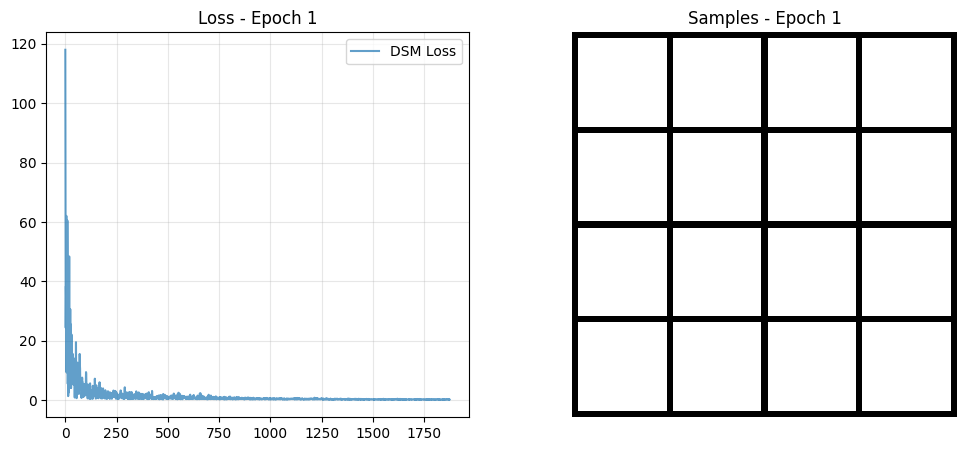

In [ ]:

def main():
    paths = RunPaths()
    paths.ensure()
    cfg = NCSNConfig()
    train(cfg, paths.images / "ncsn", conditional=False)
    train(cfg, paths.images / "ncsn_cond", conditional=True)

if __name__ == "__main__":
    main()


In [ ]:
"""
Sampling and denoising utilities for trained NCSN models.
"""

from pathlib import Path
from typing import Optional, Sequence
import torch



def load_ncsn_model(
    checkpoint: Path, cfg: NCSNConfig, conditional: bool = False
) -> ScoreNet:
    cfg.conditional = conditional
    model = ScoreNet(cfg).to(cfg.device)
    state = torch.load(checkpoint, map_location=cfg.device)
    model.load_state_dict(state["model"])
    model.eval()
    return model


@torch.no_grad()
def ncsn_generate_and_denoise(
    checkpoint: Path,
    output_dir: Path,
    cfg: NCSNConfig,
    conditional: bool = False,
    noise_levels: Sequence[float] = (0.2, 0.4, 0.6),
) -> None:
    ensure_dir(output_dir)
    # اگر دیتالودر بازه [-1, 1] می‌دهد، نیازی به تغییر دستی نیست
    data_cfg = DataConfig(batch_size=16)
    train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)
    
    model = load_ncsn_model(checkpoint, cfg, conditional)

    # 1. تولید نمونه از نویز خالص (Generation)
    y_samples: Optional[torch.Tensor] = None
    if conditional:
        y_samples = torch.arange(0, 16, device=cfg.device) % cfg.num_classes
        
    samples = sample(model, cfg, num_samples=16, y=y_samples)
    
    # هندل کردن ترجکتوری یا تنسور ساده
    if isinstance(samples, list):
        save_grid((samples[-1] + 1) / 2.0, output_dir / "ncsn_samples.png", nrow=4)
    else:
        save_grid((samples + 1) / 2.0, output_dir / "ncsn_samples.png", nrow=4)

    # 2. حذف نویز (Denoising)
    x_real, labels = next(iter(train_loader))
    
    # ⚠️ اصلاح مهم ۱: حذف نرمال‌سازی دوبل (با فرض اینکه دیتالودر [-1, 1] می‌دهد)
    x_real = x_real.to(cfg.device)[:16] 
    
    y = labels.to(cfg.device)[:16] if conditional else None

    for nl in noise_levels:
        # اضافه کردن نویز
        noise = torch.randn_like(x_real)
        noisy = x_real + nl * noise
        noisy = noisy.clamp(-1.0, 1.0) # کلمپ کردن نویز ورودی بد نیست
        
        # ⚠️ اصلاح مهم ۲: اجرای Annealing از سطح نویز nl تا انتها
        # پیدا کردن نزدیک‌ترین سیگما در لیست سیگماهای مدل به سطح نویز فعلی
        start_idx = (cfg.sigmas - nl).abs().argmin()
        
        # انتخاب دنباله سیگماها از آنجا تا آخر (به سمت کمترین نویز)
        # این باعث می‌شود تصویر کاملاً تمیز شود
        partial_sigmas = cfg.sigmas[start_idx:]
        
        denoised = annealed_langevin_dynamics(model, cfg, partial_sigmas, noisy.clone(), y)
        
        # ذخیره‌سازی
        save_grid((noisy + 1) / 2.0, output_dir / f"noisy_{nl:.2f}.png", nrow=4)
        save_grid((denoised + 1) / 2.0, output_dir / f"denoised_{nl:.2f}.png", nrow=4)

In [ ]:

def main():
    paths = RunPaths()
    paths.ensure()
    cfg = NCSNConfig()
    ncsn_generate_and_denoise(
        paths.images / "ncsn" / "ncsn.pt",
        paths.images / "ncsn_infer",
        cfg,
        conditional=False,
    )
    ncsn_generate_and_denoise(
        paths.images / "ncsn_cond" / "ncsn_cond.pt",
        paths.images / "ncsn_cond_infer",
        cfg,
        conditional=True,
    )


if __name__ == "__main__":
    main()


In [ ]:
import torch
import gc
# from ncsn_infer import load_ncsn_model
# from ncsn_sampling import sample
# from utils import save_grid

ncsn_cond_ckpt = paths.images / "ncsn_cond" / "ncsn_cond.pt"

if ncsn_cond_ckpt.exists():
    cfg = NCSNConfig(conditional=True)
    model = load_ncsn_model(ncsn_cond_ckpt, cfg, conditional=True)
    model.eval() # Ensure evaluation mode
    
    grid_dir = paths.images / "ncsn_cond_grid"
    grid_dir.mkdir(parents=True, exist_ok=True)
    
    all_samples = []
    
    print("Generating 10x10 conditional grid...")
    
    # Wrap in no_grad to prevent OOM
    with torch.no_grad():
        for digit in range(10):
            print(f"  Sampling digit {digit}...")
            # Create class labels for a row of 10
            y = torch.full((10,), digit, device=cfg.device, dtype=torch.long)
            
            # Generate the samples
            samples = sample(model, cfg, num_samples=10, y=y)
            
            # Move to CPU immediately to save GPU memory
            all_samples.append(samples.detach().cpu())
            
            # Manual memory cleanup between digits
            del samples
            torch.cuda.empty_cache()
            gc.collect()

    # 1. FIX THE CONCATENATION:
    # all_samples is a list of 10 tensors, each (10, 1, 28, 28)
    # Concatenating on dim=0 creates one big tensor of (100, 1, 28, 28)
    grid_tensor = torch.cat(all_samples, dim=0)
    
    # 2. FIX THE SAVING:
    # Map from [-1, 1] to [0, 1] and save with 10 images per row
    save_grid((grid_tensor + 1) / 2.0, grid_dir / "ncsn_cond_grid.png", nrow=10)
    
    print(f"Success! Conditional grid saved to {grid_dir / 'ncsn_cond_grid.png'}")
else:
    print("Conditional NCSN checkpoint not found.")

In [ ]:
import imageio.v2 as imageio # Fixed to avoid DeprecationWarnings
import matplotlib.pyplot as plt
from pathlib import Path
import re

def show_image(path: Path, figsize=(8, 8)):
    """Displays a single image clearly with a title."""
    if not path.exists():
        print(f"File not found: {path}")
        return
    img = plt.imread(str(path))
    plt.figure(figsize=figsize)
    plt.axis('off')
    plt.title(path.name, fontsize=10)
    plt.imshow(img)
    plt.show()

import glob
from PIL import Image
from pathlib import Path

def make_gif_from_frames(frame_dir: Path, output_path: Path, prefix: str = "ncsn_traj", fps: int = 10):
    """
    Reads all PNG images from frame_dir matching the prefix, sorts them,
    and creates an animated GIF at output_path.
    """
    # پیدا کردن تمام عکس‌ها با پسوند png و پیشوند مشخص شده
    # نکته: مرتب‌سازی (sorted) بسیار مهم است تا فریم‌ها قاطی نشوند
    frames = sorted(list(frame_dir.glob(f"{prefix}_*.png")))
    
    if not frames:
        print(f"No frames found in {frame_dir} with prefix '{prefix}'")
        return

    # باز کردن عکس‌ها با کتابخانه Pillow
    imgs = [Image.open(f) for f in frames]
    
    # محاسبه مدت زمان هر فریم بر حسب میلی‌ثانیه
    duration_ms = 1000 // fps
    
    # ذخیره فایل GIF
    imgs[0].save(
        output_path,
        save_all=True,
        append_images=imgs[1:],
        optimize=False,
        duration=duration_ms,
        loop=0  # 0 یعنی بی‌نهایت تکرار شود
    )
    print(f"GIF saved to {output_path}")
    
    
def display_saved_run_images(run_images_dir: Path, max_images: int = 5):
    """Displays a limited number of images to prevent browser/memory lag."""
    files = sorted(run_images_dir.glob("*.png"))
    if not files:
        print(f"No images found in {run_images_dir}")
        return
        
    print(f"Found {len(files)} images. Showing first {min(len(files), max_images)}:")
    for f in files[:max_images]:
        show_image(f)

In [ ]:
import torch
# from ncsn_infer import load_ncsn_model
# from ncsn_sampling import sample

ncsn_ckpt = paths.images / "ncsn" / "ncsn.pt"

if ncsn_ckpt.exists():
    # 1. Initialization
    cfg = NCSNConfig()
    model = load_ncsn_model(ncsn_ckpt, cfg, conditional=False)
    model.eval()
    
    traj_dir = paths.images / "ncsn_trajectory"
    traj_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. Memory-Safe Trajectory Generation
    print("Generating NCSN sampling trajectory...")
    with torch.no_grad():
        # Using num_samples=1 as per your code to save memory
        trajectory = sample(
            model, 
            cfg, 
            num_samples=1, 
            return_trajectory=True, 
            record_every=10
        )
    
    # 3. Saving Frames
    # trajectory is a list of tensors on CPU (if sample() is implemented correctly)
    for i, frame in enumerate(trajectory):
        save_grid((frame + 1) / 2.0, traj_dir / f"ncsn_traj_{i:03d}.png", nrow=1)
    
    print(f"Trajectory frames saved to {traj_dir}")
    
    # 4. Create GIF
    # Ensure prefix matches your save_grid naming convention
    make_gif_from_frames(traj_dir, paths.images / "ncsn_trajectory.gif", prefix="ncsn_traj", fps=10)

else:
    print("NCSN checkpoint not found.")

In [ ]:
# Create EBM Evolution GIF
make_gif_from_frames(
    frames_dir=paths.images / "ebm_trajectory", 
    out_path=paths.images / "ebm_evolution.gif",
    prefix="trajectory", 
    fps=12
)

# Create NCSN Annealing GIF
make_gif_from_frames(
    frames_dir=paths.images / "ncsn_trajectory", 
    out_path=paths.images / "ncsn_annealing.gif",
    prefix="ncsn_traj", 
    fps=12
)

In [ ]:
from pathlib import Path
import torch
import gc # For manual memory cleanup

# Assuming these are your existing imports
# from config import DataConfig, EBMConfig, RunPaths
# from data import mnist_dataloaders
# from ebm_model import ConvEnergyModel
# from ebm_sampling import sample_from_noise, LangevinSampler
# from utils import save_grid, set_seed, ensure_dir

def load_ebm_model(checkpoint: Path, device: torch.device) -> ConvEnergyModel:
    model = ConvEnergyModel().to(device)
    state = torch.load(checkpoint, map_location=device)
    model.load_state_dict(state["model"])
    model.eval()
    # CRITICAL: Freeze weights to save memory during Langevin steps
    model.requires_grad_(False) 
    return model

def ebm_generate_and_denoise(
    checkpoint: Path, output_dir: Path, data_cfg: DataConfig, ebm_cfg: EBMConfig
) -> None:
    set_seed(data_cfg.seed)
    # Ensure folder exists
    ensure_dir(output_dir)
    
    device = ebm_cfg.device
    model = load_ebm_model(checkpoint, device)
    sampler = LangevinSampler(model, ebm_cfg)

    print("Generating samples from noise...")
    # 1. Generation from scratch
    # Note: Langevin requires gradients on the images themselves, so we don't use no_grad() here.
    samples = sample_from_noise(model, ebm_cfg, (16, 1, 28, 28))
    save_grid(samples.detach().cpu(), output_dir / "ebm_samples_final.png", nrow=4)
    
    # Cleanup memory before denoising
    del samples
    torch.cuda.empty_cache()

    print("Denoising real images...")
    # 2. Denoising task
    train_loader, _ = mnist_dataloaders(data_cfg)
    x_real, _ = next(iter(train_loader))
    x_real = x_real[:16].to(device)
    
    # Add noise to simulate corruption
    noise = torch.randn_like(x_real) * 0.5 # Increased noise for visual impact
    noisy = (x_real + noise).clamp(0.0, 1.0)
    
    # Run Langevin to "purify" the image toward low energy
    denoised = sampler(noisy)
    
    # Save the comparison grid
    save_grid(x_real.detach().cpu(), output_dir / "ebm_real.png", nrow=4)
    save_grid(noisy.detach().cpu(), output_dir / "ebm_noisy.png", nrow=4)
    save_grid(denoised.detach().cpu(), output_dir / "ebm_denoised.png", nrow=4)
    
    print(f"Results saved to {output_dir}")
    
    # Final cleanup
    del model, sampler
    gc.collect()
    torch.cuda.empty_cache()

# Usage logic
if __name__ == "__main__":
    paths = RunPaths()
    ebm_ckpt = paths.images  / "ebm_ckpt.pt"
    if ebm_ckpt.exists():
        ebm_generate_and_denoise(ebm_ckpt, paths.images / "ebm_infer", DataConfig(), EBMConfig())
    else:
        print("EBM checkpoint not found.")

In [ ]:
import torch
import gc
from pathlib import Path
from typing import Optional, Sequence

# # Ensuring all necessary components are available
# from ncsn_model import ScoreNet
# from ncsn_sampling import sample, annealed_langevin_dynamics
# from utils import save_grid, ensure_dir

@torch.no_grad()
def ncsn_generate_and_denoise(
    checkpoint: Path,
    output_dir: Path,
    cfg: NCSNConfig,
    conditional: bool = False,
    noise_levels: Sequence[float] = (0.3, 0.6, 0.9),
) -> None:
    ensure_dir(output_dir)
    device = cfg.device
    
    # 1. Load Model and Freeze
    model = load_ncsn_model(checkpoint, cfg, conditional)
    model.requires_grad_(False) # Memory protection
    
    # 2. Pure Generation
    print(f"Generating samples (Conditional={conditional})...")
    y_samples = None
    if conditional:
        y_samples = torch.arange(0, 16, device=device) % 10
    
    samples = sample(model, cfg, num_samples=16, y=y_samples)
    save_grid((samples.cpu() + 1) / 2.0, output_dir / "ncsn_samples.png", nrow=4)
    
    # Clear memory after generation
    del samples
    torch.cuda.empty_cache()

    # 3. Denoising Real Images
    print("Running denoising experiments...")
    data_cfg = DataConfig(batch_size=16)
    train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)
    
    x_real, labels = next(iter(train_loader))
    x_real = (x_real.to(device) * 2 - 1)[:16]
    y = labels.to(device)[:16] if conditional else None
    
    # Save original for comparison
    save_grid((x_real.cpu() + 1) / 2.0, output_dir / "real_original.png", nrow=4)

    for nl in noise_levels:
        print(f"  Processing noise level: {nl}")
        # Add noise
        noisy = x_real + nl * torch.randn_like(x_real)
        
        # THEORY FIX: To denoise properly, we should run ALD using only the 
        # sigmas in our schedule that are LESS than or equal to the noise level nl.
        relevant_sigmas = cfg.sigmas[cfg.sigmas <= nl]
        if len(relevant_sigmas) == 0:
            relevant_sigmas = torch.tensor([nl], device=device)
            
        denoised = annealed_langevin_dynamics(model, cfg, relevant_sigmas, noisy.clone(), y)
        
        save_grid((noisy.cpu() + 1) / 2.0, output_dir / f"noisy_{nl:.2f}.png", nrow=4)
        save_grid((denoised.cpu() + 1) / 2.0, output_dir / f"denoised_{nl:.2f}.png", nrow=4)
        
        # Clean up each loop
        torch.cuda.empty_cache()
        gc.collect()

    print(f"Inference complete. Results in {output_dir}")

In [ ]:
import torch
import gc
from pathlib import Path

def main():
    # 1. Setup Paths and Configs
    paths = RunPaths()
    paths.ensure()
    ebm_cfg = EBMConfig()
    ncsn_cfg = NCSNConfig()
    
    # --- TASK 1: EBM RESULTS (Question 1) ---
    ebm_ckpt = paths.images  / "ebm_ckpt.pt"
    if ebm_ckpt.exists():
        print(">>> Processing EBM Inference...")
        ebm_generate_and_denoise(
            ebm_ckpt, 
            paths.images / "ebm_results", 
            DataConfig(), 
            ebm_cfg
        )
        
        # Generate EBM Trajectory GIF
        # (Assuming your ebm_sample_traj function was run or defined)
        make_gif_from_frames(
            paths.images / "ebm_trajectory", 
            paths.images / "ebm_trajectory.gif", 
            prefix="trajectory", 
            fps=12
        )
    
    # Cleanup EBM from GPU
    torch.cuda.empty_cache()
    gc.collect()

    # --- TASK 2: NCSN UNCONDITIONAL (Question 2) ---
    ncsn_ckpt = paths.images  / "ncsn.pt"
    if ncsn_ckpt.exists():
        print("\n>>> Processing NCSN Unconditional...")
        ncsn_generate_and_denoise(
            ncsn_ckpt, 
            paths.images / "ncsn_infer", 
            ncsn_cfg, 
            conditional=False
        )
        
        # Generate NCSN Trajectory GIF
        make_gif_from_frames(
            paths.images / "ncsn_trajectory", 
            paths.images / "ncsn_trajectory.gif", 
            prefix="ncsn_traj", 
            fps=12
        )

    # Cleanup Unconditional from GPU
    torch.cuda.empty_cache()
    gc.collect()

    # --- TASK 3: NCSN CONDITIONAL (Question 2 - 10x10 Grid) ---
    ncsn_cond_ckpt = paths.images / "ncsn_cond" / "ncsn_cond.pt"
    if ncsn_cond_ckpt.exists():
        print("\n>>> Processing NCSN Conditional 10x10 Grid...")
        # Re-using your specific 10x10 grid logic
        model = load_ncsn_model(ncsn_cond_ckpt, ncsn_cfg, conditional=True)
        grid_dir = paths.images / "ncsn_cond_grid"
        grid_dir.mkdir(exist_ok=True)
        
        all_samples = []
        with torch.no_grad():
            for digit in range(10):
                y = torch.full((10,), digit, device=ncsn_cfg.device, dtype=torch.long)
                samples = sample(model, ncsn_cfg, num_samples=10, y=y)
                all_samples.append(samples.detach().cpu())
                del samples
        
        grid_tensor = torch.cat(all_samples, dim=0)
        save_grid((grid_tensor + 1) / 2.0, grid_dir / "ncsn_cond_grid.png", nrow=10)
        print(f"Success: 10x10 grid saved to {grid_dir}")

    print("\n[FINISHED] All images and GIFs for your report are ready in /kaggle/working/images/")

if __name__ == "__main__":
    main()

In [ ]:
import torch
import gc
# from ebm_infer import load_ebm_model # Note the name change to match your previous cell
# from ebm_sampling import LangevinSampler

ck = paths.images  / 'ebm_ckpt.pt'
out = paths.images / 'ebm_posttrain_init'
out.mkdir(parents=True, exist_ok=True)

if ck.exists():
    cfg = EBMConfig()
    device = cfg.device
    
    # 1. Load model and FREEZE weights to save memory
    model = load_ebm_model(ck, device)
    model.requires_grad_(False) 
    sampler = LangevinSampler(model, cfg)
    
    # 2. Use normalize_to_minus1_1=True to match EBM training range [-1, 1]
    data_cfg = DataConfig(batch_size=16)
    train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)
    
    # 3. Get real data
    x_real, _ = next(iter(train_loader))
    x_real = x_real.to(device)
    
    print("Running Langevin sampling starting from real images...")
    # Langevin requires gradients on the INPUT pixels, not the model weights
    # The sampler will move x_real toward even lower energy states
    x_sampled = sampler(x_real)
    
    # 4. Save results (Map back to [0, 1] for display)
    real_display = (x_real.detach().cpu() + 1) / 2.0
    sampled_display = (x_sampled.detach().cpu() + 1) / 2.0
    
    save_grid(real_display, out / 'post_init_real.png', nrow=4)
    save_grid(sampled_display, out / 'post_init_sampled.png', nrow=4)
    
    print('Saved post-training init images to', out)
    
    # Cleanup
    del x_real, x_sampled, model
    torch.cuda.empty_cache()
    gc.collect()
else:
    print('No EBM checkpoint found at', ck)

In [ ]:
import torch
import gc
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from IPython.display import Image, display

# 1. Setup and Model Loading
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
out_dir = paths.images / 'ebm_langevin_walkthrough'
frames_dir = out_dir / 'frames'
frames_dir.mkdir(parents=True, exist_ok=True)

# Load model (Ensuring weights are frozen to save GPU memory)
model = ConvEnergyModel().to(device)
ck = paths.images  / 'ebm_ckpt.pt'
if ck.exists():
    state = torch.load(ck, map_location=device)
    model.load_state_dict(state['model'])
    print('Loaded EBM checkpoint.')
model.eval()
model.requires_grad_(False) # Weights don't need grads, only the image 'x' does

# 2. Data Preparation
# EBMs are sensitive to normalization; ensure this matches your training (-1 to 1)
data_cfg = DataConfig(batch_size=1)
train_loader, _ = mnist_dataloaders(data_cfg, normalize_to_minus1_1=True)
x_real, _ = next(iter(train_loader))
x_real = x_real.to(device)
x_init = torch.randn_like(x_real).to(device) # Noise typically starts standard normal

# 3. Langevin Loop
T = 100
record_every = 10
eta = 0.01 # Step size (usually smaller than 0.1 for stability)
x = x_init.clone().detach()
energy_trace = []

print("Running Langevin walkthrough steps...")
for t in range(1, T + 1):
    x.requires_grad_(True)
    
    # Forward pass to get energy
    E = model(x).mean()
    
    # Calculate gradient of Energy w.r.t. the Image
    grad = torch.autograd.grad(E, x)[0]
    
    with torch.no_grad():
        # Step: x = x - (learning_rate * grad) + noise
        x = x - 0.5 * eta * grad + torch.randn_like(x) * (eta ** 0.5)
        x = x.clamp(-1.0, 1.0) # Match training range
        
        energy_trace.append(E.item())
        
        # Save frame (Map back to 0-1 for visualization)
        if t % record_every == 0 or t == 1:
            disp_x = (x.detach().cpu() + 1) / 2.0
            save_image(disp_x, frames_dir / f'frame_{t:03d}.png')
    
    # Detach x to break the graph and save VRAM
    x = x.detach()

# 4. Final Visualizations
print("Generating final plots...")
save_image((x_init.cpu() + 1) / 2.0, out_dir / 'init.png')
save_image((x.cpu() + 1) / 2.0, out_dir / 'final.png')
save_image((x_real.cpu() + 1) / 2.0, out_dir / 'real.png')

# Plot Energy Trace
plt.figure(figsize=(6, 4))
plt.plot(energy_trace, color='red', lw=2)
plt.title("Energy Minimization Trace")
plt.xlabel("Step")
plt.ylabel("Energy $E_\theta(x)$")
plt.grid(True, alpha=0.3)
plt.savefig(out_dir / 'energy_trace.png')
plt.close()

# GIF Creation using natural sort to ensure correct order
try:
    make_gif_from_frames(frames_dir, out_dir / 'langevin_walk.gif', prefix='frame_', fps=10)
    display(Image(filename=str(out_dir / 'langevin_walk.gif')))
except Exception as e:
    print(f"GIF failed: {e}")

torch.cuda.empty_cache()
gc.collect()

In [ ]:
import torch
import gc
import json
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

# 1. Config & Paths
SWEEP_QUICK = True
etas = [0.01, 0.05, 0.1] if SWEEP_QUICK else [0.005, 0.01, 0.02, 0.05, 0.1]
Ts = [20, 100, 300] if SWEEP_QUICK else [20, 50, 100, 300, 600]

out_root = paths.images / 'ebm_langevin_sweep'
out_root.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Model Loading
model = ConvEnergyModel().to(device)
ck = paths.images  / 'ebm_ckpt.pt'
if ck.exists():
    state = torch.load(ck, map_location=device)
    model.load_state_dict(state['model'])
    print('Loaded EBM for sweep.')
model.eval()
model.requires_grad_(False) # Freeze weights to save memory

# 3. Setup Initial Condition
set_seed(42)
# Using normalize_to_minus1_1=True to match EBM training range
train_loader, _ = mnist_dataloaders(DataConfig(), normalize_to_minus1_1=True)
x_real, _ = next(iter(train_loader))
x_real = x_real[:1].to(device)
x_init = torch.randn_like(x_real).to(device) # Standard normal init

final_images = []
summary_records = []

# 4. Sweep Execution
print(f"Starting sweep over {len(Ts)}x{len(etas)} configurations...")
for T in Ts:
    row_images = []
    for eta in etas:
        x = x_init.clone().detach()
        energy_trace = []
        
        for t in range(1, T + 1):
            x.requires_grad_(True)
            E = model(x).mean()
            # Gradient of Energy w.r.t Image
            grad = torch.autograd.grad(E, x)[0]
            
            with torch.no_grad():
                # Langevin Update
                x = x - 0.5 * eta * grad + torch.randn_like(x) * (eta ** 0.5)
                x = x.clamp(-1.0, 1.0)
                energy_trace.append(E.item())
            x = x.detach() # Essential for memory

        # Save individual run metrics
        run_name = f'eta{eta:.4f}_T{T}'
        disp_x = (x.cpu() + 1) / 2.0 # Map back to [0,1]
        save_image(disp_x, out_root / f'final_{run_name}.png')
        
        # Track for the final grid
        row_images.append(disp_x)
        summary_records.append({'T': T, 'eta': eta, 'energy_final': E.item()})
        
        # Individual Energy Plot
        plt.figure(figsize=(4, 2))
        plt.plot(energy_trace)
        plt.title(f"$\eta$={eta}, T={T}")
        plt.savefig(out_root / f'energy_{run_name}.png')
        plt.close()

    final_images.append(torch.cat(row_images, dim=0))
    # Clear cache between T-rows
    torch.cuda.empty_cache()
    gc.collect()

# 5. Save Final Comparison Grid
all_rows = torch.cat(final_images, dim=0)
grid_img = make_grid(all_rows, nrow=len(etas))
save_image(grid_img, out_root / 'sweep_grid.png')

with open(out_root / 'sweep_summary.json', 'w') as f:
    json.dump(summary_records, f, indent=2)

print(f'Sweep complete. Grid saved at {out_root / "sweep_grid.png"}')

In [ ]:
import matplotlib.pyplot as plt

if "ebm_hist" in locals() and ebm_hist:
    plt.figure(figsize=(6, 4))
    plt.plot(ebm_hist["loss"])
    plt.title("EBM Loss (demo)")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(paths.images / "ebm_demo_loss.png")
    plt.show()
else:
    print("Run the demo cell to populate ebm_hist.")

if "ncsn_hist" in locals() and ncsn_hist:
    plt.figure(figsize=(6, 4))
    plt.plot(ncsn_hist["loss"])
    plt.title("NCSN DSM Loss (demo)")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(paths.images / "ncsn_demo_loss.png")
    plt.show()
else:
    print("Run the demo cell to populate ncsn_hist.")

In [53]:
import shutil

# This zips the entire 'images' folder into a file named 'my_results.zip'
shutil.make_archive('my_results', 'zip', '/kaggle/working/images')

print("Zip file created successfully!")

Zip file created successfully!
